<a href="https://colab.research.google.com/github/raihanahmada/Probabilitas-Dan-Statistika/blob/main/Statistika_Deskriptif_Raihan_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Penyajian Data dan Statistika Deskriptif Menggunakan Python
**Nama :** Raihan Ahmada Siahaan  
**NIM :** 2455301234  
**Mata Kuliah :** Statistika dan Probabilitas — Pertemuan 4

## Import Library & Baca File Excel

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)

def judul(teks):
    print("=" * 60)
    print(f" {teks}")
    print("=" * 60)

# File Raihan.xlsx sudah diupload di panel Files Google Colab
path = "Raihan.xlsx"
print("File yang dipakai:", path)

NAMA = "Raihan Ahmada Siahaan"
NIM  = 2455301234

File yang dipakai: Raihan.xlsx


## A. Pengorganisasian Data
### A.1 Tabel Data Mentah

In [11]:
dataraw = pd.read_excel(path, sheet_name="Data")
ref     = pd.read_excel(path, sheet_name="Referensi", header=None)

# Bobot nilai diambil dari sheet Referensi
bobot = {"KUIS": float(ref.iloc[1, 1]), "UTS": float(ref.iloc[2, 1]), "UAS": float(ref.iloc[3, 1])}

def hitung_grade(n):
    if n >= 81: return "A"
    if n >= 76: return "AB"
    if n >= 66: return "B"
    if n >= 61: return "BC"
    if n >= 51: return "C"
    return "F"

# Hitung ulang Nilai, Grade, dan Ket di Python
dataraw["Nilai"] = (dataraw["KUIS"] * bobot["KUIS"] +
                    dataraw["UTS"]  * bobot["UTS"]  +
                    dataraw["UAS"]  * bobot["UAS"]).round(2)
dataraw["Grade"] = dataraw["Nilai"].apply(hitung_grade)
dataraw["Ket"]   = dataraw["Grade"].apply(lambda g: "Tidak Lulus" if g == "F" else "Lulus")

judul(f"TABEL DATA MENTAH - {NAMA} ({NIM})")
print("Bobot nilai :", bobot)
print(dataraw.to_string())
print(f"\nJumlah data : {len(dataraw)} mahasiswa")

 TABEL DATA MENTAH - Raihan Ahmada Siahaan (2455301234)
Bobot nilai : {'KUIS': 0.32, 'UTS': 0.33, 'UAS': 0.35}
           NIM                   Name  KUIS  UTS  UAS  Nilai Grade          Ket
0   2455301234  Raihan Ahmada Siahaan    77   67   90  78.25    AB        Lulus
1       120001               John Doe    85   78   90  84.44     A        Lulus
2       120005             Jane Smith    92   88   94  91.38     A        Lulus
3       120017        Michael Johnson    48   65   56  56.41     C        Lulus
4       120018            Emily Brown    90   85   88  87.65     A        Lulus
5       120022        Daniel Martinez    75   80   77  77.35    AB        Lulus
6       120024           Sarah Wilson    88   70   65  74.01     B        Lulus
7       120025           David Garcia    75   70   75  73.35     B        Lulus
8       120027            Jessica Lee    95   91   96  94.03     A        Lulus
9       120034          Matthew Davis    79   84   78  80.30    AB        Lulus
10      1

### A.2 Tabel Frekuensi

In [12]:
urutan_grade = [g for g in ["A", "AB", "B", "BC", "C", "D", "E", "F"] if g in dataraw["Grade"].unique()]

datafrq = pd.crosstab(index=dataraw["Grade"], columns="Frekuensi").reindex(urutan_grade)

judul("TABEL FREKUENSI GRADE")
print(datafrq)

tabel_persen = datafrq.copy()
tabel_persen.columns.name = None
tabel_persen["Persentase (%)"] = (tabel_persen["Frekuensi"] / tabel_persen["Frekuensi"].sum() * 100).round(1)
tabel_persen.loc["Total"] = [tabel_persen["Frekuensi"].sum(), round(tabel_persen["Persentase (%)"].sum())]
print("\nTabel frekuensi + persentase:")
print(tabel_persen)

 TABEL FREKUENSI GRADE
col_0  Frekuensi
Grade           
A             12
AB             8
B              4
BC             1
C              5
F              1

Tabel frekuensi + persentase:
       Frekuensi  Persentase (%)
Grade                           
A             12            38.7
AB             8            25.8
B              4            12.9
BC             1             3.2
C              5            16.1
F              1             3.2
Total         31           100.0


## B. Penyajian Data
### B.1 Grafik Garis

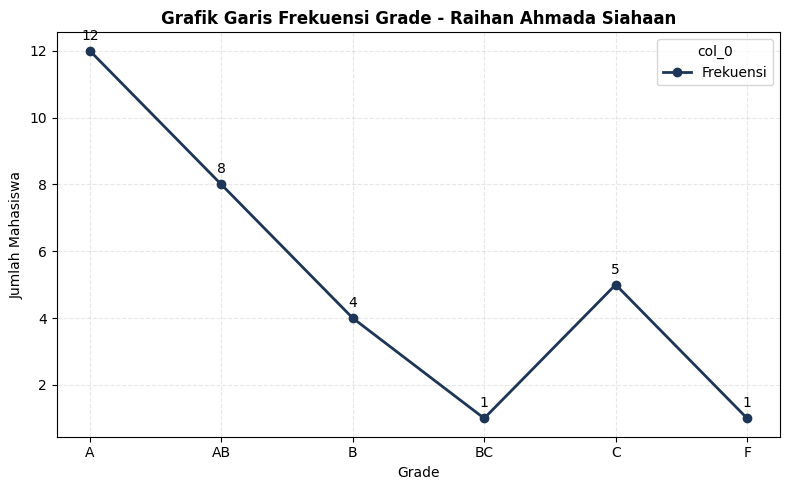

In [13]:
warna = ["#1D3557", "#457B9D", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51", "#6A4C93", "#555555"]

ax = datafrq.plot(marker="o", color="#1D3557", linewidth=2, figsize=(8, 5))
ax.set_title(f"Grafik Garis Frekuensi Grade - {NAMA}", fontweight="bold")
ax.set_xlabel("Grade")
ax.set_ylabel("Jumlah Mahasiswa")
ax.grid(alpha=0.3, linestyle="--")
for i, v in enumerate(datafrq["Frekuensi"]):
    ax.annotate(str(v), (i, v), textcoords="offset points", xytext=(0, 8), ha="center")
plt.tight_layout()
plt.show()

### B.2 Grafik Batang

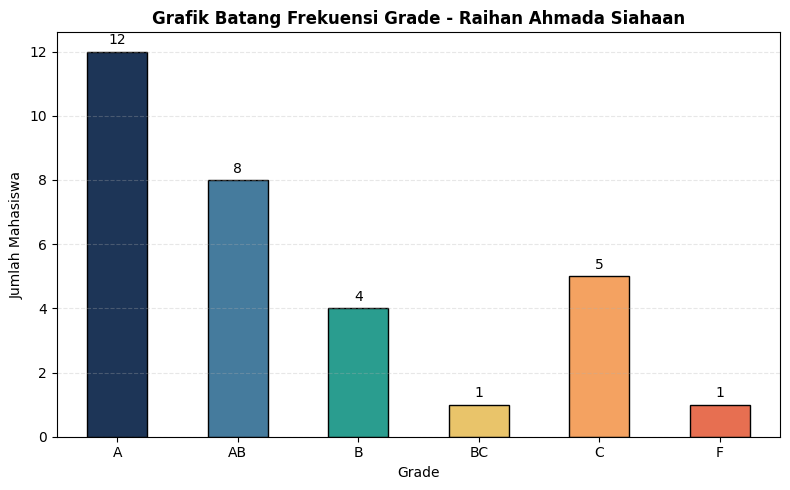

In [14]:
ax = datafrq.plot(kind="bar", edgecolor="black", figsize=(8, 5), legend=False)
for bar, c in zip(ax.patches, warna):
    bar.set_facecolor(c)
ax.set_title(f"Grafik Batang Frekuensi Grade - {NAMA}", fontweight="bold")
ax.set_xlabel("Grade")
ax.set_ylabel("Jumlah Mahasiswa")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.3, linestyle="--")
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", xytext=(0, 3), textcoords="offset points")
plt.tight_layout()
plt.show()

### B.3 Pie Chart

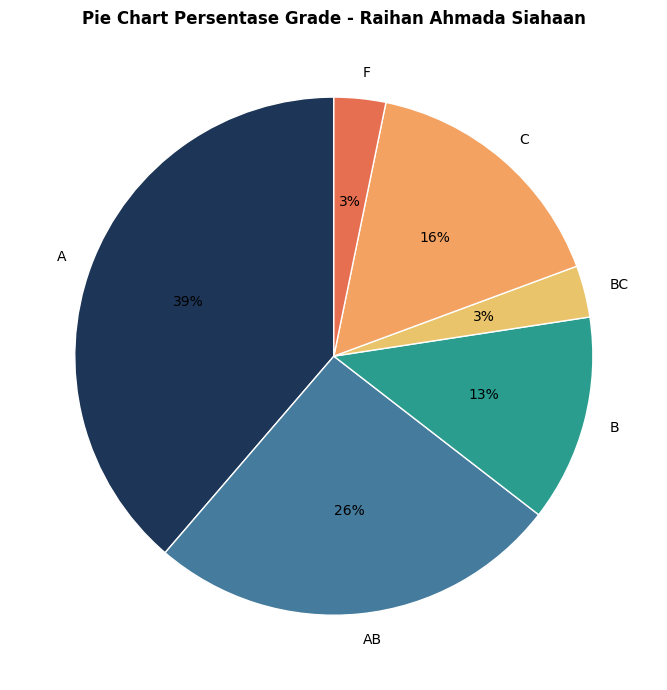

In [15]:
ax = datafrq.plot(kind="pie", y="Frekuensi", autopct="%1.0f%%", legend=False,
                  colors=warna[:len(datafrq)], startangle=90,
                  wedgeprops={"edgecolor": "white"}, figsize=(7, 7))
ax.set_title(f"Pie Chart Persentase Grade - {NAMA}", fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## C. Statistika Deskriptif
### C.1 Statistik Nilai Akhir

In [16]:
dataraw["Nilai"] = pd.to_numeric(dataraw["Nilai"], errors="coerce")
dt = dataraw["Nilai"]

stats = dt.describe()
stats["Standard Error"] = dt.sem()
stats["Median"]   = dt.median()
stats["Mode"]     = dt.mode().iloc[0]
stats["variance"] = dt.var()
stats["range"]    = dt.max() - dt.min()
stats["skewness"] = dt.skew()
stats["kurtosis"] = dt.kurtosis()

judul("STATISTIKA DESKRIPTIF NILAI AKHIR")
print(stats)

 STATISTIKA DESKRIPTIF NILAI AKHIR
count              31.000000
mean               76.286774
std                13.245253
min                46.010000
25%                68.800000
50%                78.300000
75%                86.790000
max                94.030000
Standard Error      2.378918
Median             78.300000
Mode               77.300000
variance          175.436716
range              48.020000
skewness           -0.688943
kurtosis           -0.427403
Name: Nilai, dtype: float64


### C.2 Analisis Tambahan

In [17]:
q1, q3 = dt.quantile(0.25), dt.quantile(0.75)
iqr = q3 - q1
batas_bawah, batas_atas = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outlier = dataraw[(dt < batas_bawah) | (dt > batas_atas)]

judul("ANALISIS TAMBAHAN")
print(f"Semua nilai modus      : {dt.mode().tolist()}")
print(f"Selisih Mean - Median  : {dt.mean() - dt.median():.2f}")
print(f"IQR (Q3 - Q1)          : {iqr:.2f}")
print(f"Batas bawah outlier    : {batas_bawah:.2f}")
print(f"Batas atas outlier     : {batas_atas:.2f}")
print(f"Jumlah outlier         : {len(outlier)}")
if len(outlier) > 0:
    print(outlier[["NIM", "Name", "Nilai", "Grade"]].to_string(index=False))
print(f"SD / Mean x 100%       : {dt.std() / dt.mean() * 100:.2f}%")

print("\nRata-rata per komponen nilai:")
print(dataraw[["KUIS", "UTS", "UAS", "Nilai"]].mean().round(2).to_string())

print("\nJumlah mahasiswa berdasarkan keterangan:")
print(dataraw["Ket"].value_counts().to_string())

print(f"\nPosisi data pribadi ({dataraw.loc[0, 'Name']}): Nilai {dt[0]}, Grade {dataraw.loc[0, 'Grade']}, "
      f"peringkat {int(dt.rank(ascending=False, method='min')[0])} dari {len(dt)}")

 ANALISIS TAMBAHAN
Semua nilai modus      : [77.3, 80.3]
Selisih Mean - Median  : -2.01
IQR (Q3 - Q1)          : 17.99
Batas bawah outlier    : 41.81
Batas atas outlier     : 113.78
Jumlah outlier         : 0
SD / Mean x 100%       : 17.36%

Rata-rata per komponen nilai:
KUIS     76.13
UTS      76.71
UAS      76.03
Nilai    76.29

Jumlah mahasiswa berdasarkan keterangan:
Ket
Lulus          30
Tidak Lulus     1

Posisi data pribadi (Raihan Ahmada Siahaan): Nilai 78.25, Grade AB, peringkat 17 dari 31


### Simpan tabel hasil (untuk diupload ke GCR)

In [9]:
with pd.ExcelWriter("raihan_hasil_python.xlsx") as w:
    dataraw.to_excel(w, sheet_name="Data", index=False)
    tabel_persen.to_excel(w, sheet_name="Frekuensi")
    stats.to_frame("Nilai").to_excel(w, sheet_name="Statistik")
files.download("raihan_hasil_python.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>